## 1) Configuración inicial

Vamos a definir:
- Rutas de entrada/salida
  
- Importar librerías base

**Convención**:
- Inputs: `data/videos/`
- Outputs: `outputs/videos/`

In [2]:
import os
import cv2
import numpy as np

VIDEO_IN  = "data/videos/videoTM_02.mkv"
VIDEO_OUT = "outputs/videos/videoTM_02_tracked.mp4"


print("VIDEO_IN :", VIDEO_IN)
print("VIDEO_OUT:", VIDEO_OUT)

VIDEO_IN : data/videos/videoTM_02.mkv
VIDEO_OUT: outputs/videos/videoTM_02_tracked.mp4


## 2) Verificar que el video abre correctamente

Antes de correr modelos, confirmamos:
- que el video existe
- que OpenCV puede leerlo
- FPS y resolución
- leer un primer frame real (para pruebas)

In [3]:
if not os.path.exists(VIDEO_IN):
    raise FileNotFoundError(f"No existe el video en la ruta: {VIDEO_IN}")

cap = cv2.VideoCapture(VIDEO_IN)
if not cap.isOpened():
    raise RuntimeError("OpenCV no pudo abrir el video.")

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

ok, frame0 = cap.read()
cap.release()

print("Se abrió:", ok)
print("FPS:", fps)
print("Resolución:", (w, h))


Se abrió: True
FPS: 30.0
Resolución: (640, 480)


## 3) Instalar dependencias en el kernel correcto

En Jupyter, a veces el notebook usa un Python distinto al del sistema.
Por eso instalamos con:

`{sys.executable} -m pip install ...`

Así garantizamos que se instale en el entorno del kernel actual.

In [4]:
import sys
print("Python del kernel:", sys.executable)

!{sys.executable} -m pip install -U ultralytics supervision opencv-python

Python del kernel: /usr/local/bin/python
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 30.4 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 23.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 810.4/810.4 kB 20.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 MB 24.9 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 19.4 MB/s  0:00:40m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 22.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 20.8 MB/s  0:00:26m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 26.9 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 23.3 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 16.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━

## 4) Cargar el detector YOLOv8

Usaremos `yolov8n.pt` por ser liviano

- `conf`: umbral mínimo de confianza para aceptar una detección
- `iou`: umbral de solapamiento para NMS (eliminar cajas duplicadas)



In [5]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
print(" YOLO cargado")

WARNING ⚠️ user config directory '/root/.config/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 YOLO cargado



## 5) Prueba rápida: detectar en 1 frame y visualizar

Esto sirve para validar que:
- el modelo corre
- devuelve cajas
- podemos ver resultados



Detecciones en frame0: 3


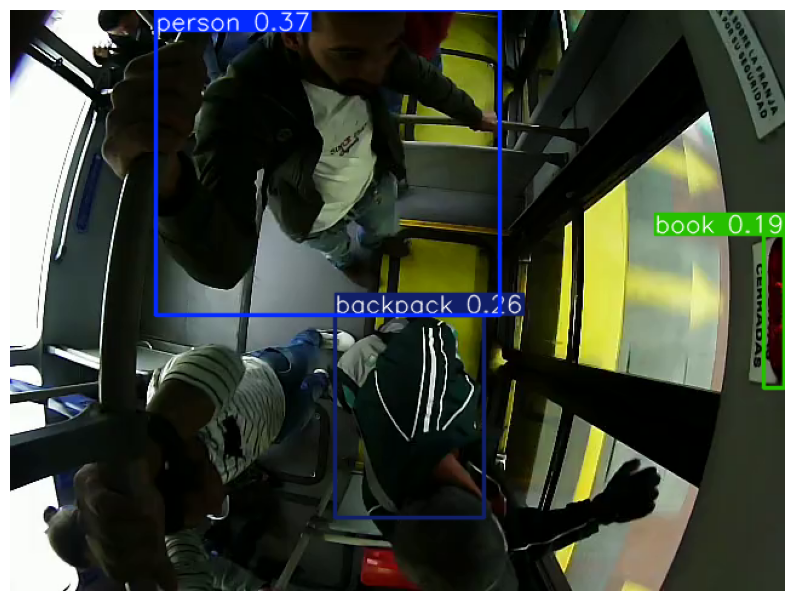

In [6]:
import matplotlib.pyplot as plt

CONF_TEST = 0.18
IOU_TEST  = 0.40

results0 = model(frame0, conf=CONF_TEST, iou=IOU_TEST, verbose=False)[0]
print("Detecciones en frame0:", len(results0.boxes))

# Dibuja cajas sobre el frame 
annotated0 = results0.plot()

plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(annotated0, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## 6) Si en el primer frame no detecta bien: tomar un frame más adelante

A veces el primer frame está:
- vacío
- oscuro
- sin objetos relevantes
- o las personas están muy pequeñas



Frame leído: True
Detecciones en frame300: 2


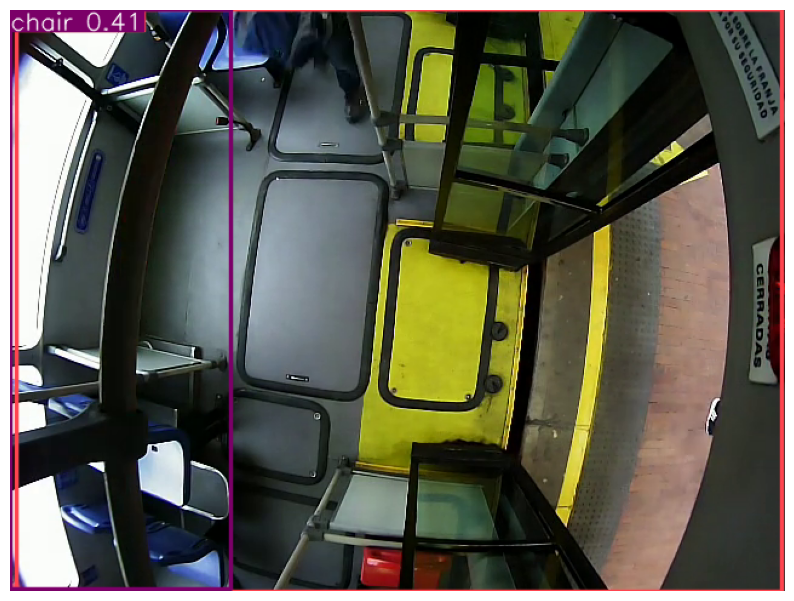

In [8]:
def get_frame_at(video_path: str, frame_index: int):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("No se pudo abrir el video para extraer frame.")
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame = cap.read()
    cap.release()
    return ok, frame

FRAME_INDEX = 200  # cambia este número si quieres
ok, frame200 = get_frame_at(VIDEO_IN, FRAME_INDEX)

print("Frame leído:", ok)
if ok:
    results200 = model(frame200, conf=0.25, iou=0.50, verbose=False)[0]
    print("Detecciones en frame300:", len(results200.boxes))
    annotated200 = results200.plot()
    plt.figure(figsize=(10,8))
    plt.imshow(cv2.cvtColor(annotated200, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

## 7) Configurar el tracker ByteTrack + anotadores

- **ByteTrack** asocia detecciones entre frames y asigna **IDs**
- Los **annotators** dibujan:
  - cajas
  - etiquetas (IDs)

> Nota: el tracker depende totalmente de las detecciones.
> Si el detector falla (pocas detecciones), el tracking será inestable.

In [9]:
import supervision as sv

tracker = sv.ByteTrack()
box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_thickness=1, text_scale=0.6)

print("ByteTrack + anotadores listos")

ByteTrack + anotadores listos


## 8) Tracking completo: generar video con IDs (modo PRUEBA)

Para no esperar demasiado en CPU, primero procesamos solo `MAX_FRAMES` frames.

Parámetros:
- `CONF`: si está muy alto, detecta poco. Si está muy bajo, mete falsos positivos.
- `MAX_FRAMES`: prueba corta. Luego lo pones en `None` para todo el video.

Filtro:
- Por defecto filtramos **solo personas** (COCO `class_id = 0`).



In [15]:
# --- Parámetros de ejecución ---
CONF = 0.30
IOU  = 0.10
MAX_FRAMES = 400   # prueba rápida; pon None para todo el video

# Abrir video
cap = cv2.VideoCapture(VIDEO_IN)
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Writer
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(VIDEO_OUT, fourcc, fps, (w, h))

frame_i = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break
    frame_i += 1

    # 1) Detección YOLO
    res = model.predict(frame, conf=CONF, iou=IOU, verbose=False)[0]
    det = sv.Detections.from_ultralytics(res)

    # 2) Filtrar SOLO personas (COCO: person = 0)
    if det.class_id is not None:
        det = det[det.class_id == 0]

    # 3) Tracking (asigna IDs)
    det = tracker.update_with_detections(det)

    # 4) Labels con ID
    labels = []
    if det.tracker_id is not None:
        for i in range(len(det)):
            tid = int(det.tracker_id[i])
            conf_det = float(det.confidence[i]) if det.confidence is not None else 0.0
            labels.append(f"ID {tid} ({conf_det:.2f})")

    # 5) Dibujar y guardar frame
    annotated = frame.copy()
    annotated = box_annotator.annotate(annotated, det)
    annotated = label_annotator.annotate(annotated, det, labels=labels)
    out.write(annotated)

    # Progreso
    if frame_i % 60 == 0:
        print(f"Procesados {frame_i} frames...")

    if MAX_FRAMES is not None and frame_i >= MAX_FRAMES:
        print("Corte de prueba alcanzado.")
        break

cap.release()
out.release()

print("Video guardado en:", VIDEO_OUT)

Procesados 60 frames...
Procesados 120 frames...
Procesados 180 frames...
Procesados 240 frames...
Procesados 300 frames...
Procesados 360 frames...
Corte de prueba alcanzado.
Video guardado en: outputs/videos/videoTM_02_tracked.mp4
